# 13 · 정착과 이음 — KDS 14 20 52

| 항목 | 식 | 조문 |
|---|---|---|
| 인장 기본정착길이 | $l_{db} = 0.6d_bf_y/(\lambda\sqrt{f_{ck}})$ | 식 (4.1-1) |
| 보정계수 | 0.8/1.0/1.2/1.5 $\times \alpha\beta$ | 표 4.1-1 |
| 인장 정밀식 | $0.90d_bf_y\alpha\beta\gamma/(\lambda\sqrt{f_{ck}}\cdot(c{+}K_{tr})/d_b)$ | 식 (4.1-2) |
| 압축 정착길이 | $\max(0.25d_bf_y/(\lambda\sqrt{f_{ck}}),\ 0.043d_bf_y)$ | 식 (4.1-3) |
| 표준갈고리 | $0.24\beta d_bf_y/(\lambda\sqrt{f_{ck}})$ | 4.1.5 |
| 압축 겹침이음 | $0.072f_yd_b$ / $(0.13f_y{-}24)d_b$ | 4.5 |

In [1]:
%matplotlib inline

import matplotlib.pyplot as plt
import numpy as np

# 한글 글꼴이 없는 환경에서도 그림이 깨지지 않도록 축 라벨은 ASCII 로 둔다
plt.rcParams["axes.unicode_minus"] = False
plt.rcParams["figure.dpi"] = 96

In [2]:
from concreteproperties_kds.detailing import (
    BAR_PROPERTIES,
    development_length_tension,
    development_length_tension_detailed,
    minimum_bar_spacing,
    summarise_detailing,
)

FCK, FY = 27.0, 400.0

summarise_detailing(bar="D22", fy=FY, fck=FCK).print_results()

정착·이음 길이 - D22 (KDS 14 20 52)
공칭 지름              db   =     22.20 mm
인장 정착길이          ld   =    1025.4 mm
압축 정착길이          ldc  =     427.2 mm
표준갈고리 정착길이    ldh  =     410.1 mm
인장 겹침이음 (A급)         =    1025.4 mm
인장 겹침이음 (B급)         =    1333.0 mm
압축 겹침이음               =     639.4 mm


## 철근 호칭별 정착·이음 길이

In [3]:
print(f"{'호칭':>6} {'db':>7} {'ld':>9} {'ld(상부)':>10} {'ldc':>8}"
      f" {'ldh':>8} {'이음B급':>9}")
print("-" * 62)
for bar in BAR_PROPERTIES:
    summary = summarise_detailing(bar=bar, fy=FY, fck=FCK)
    l_top = development_length_tension(
        bar=bar, fy=FY, fck=FCK, top_bar=True
    )
    print(
        f"{bar:>6} {summary.d_b:7.2f} {summary.l_d:9.1f} {l_top:10.1f}"
        f" {summary.l_dc:8.1f} {summary.l_dh:8.1f}"
        f" {summary.l_s_tension_b:9.1f}"
    )

    호칭      db        ld     ld(상부)      ldc      ldh      이음B급
--------------------------------------------------------------
   D10    9.53     352.1      457.8    200.0    176.1     457.8
   D13   12.70     469.3      610.1    244.4    234.6     610.1
   D16   15.90     587.5      763.8    306.0    293.8     763.8
   D19   19.10     882.2     1146.8    367.6    352.9    1146.8
   D22   22.20    1025.4     1333.0    427.2    410.1    1333.0
   D25   25.40    1173.2     1525.1    488.8    469.3    1525.1
   D29   28.60    1321.0     1717.3    550.4    528.4    1717.3
   D32   31.80    1468.8     1909.4    612.0    587.5    1909.4
   D35   34.90    1612.0     2095.6    671.7    644.8    2095.6
   D38   38.10    1759.8     2287.7    733.2    703.9    2287.7
   D41   41.30    1907.6     2479.8    794.8    763.0    2479.8
   D51   50.80    2346.4     3050.3    977.6    938.5    3050.3


## 콘크리트 강도의 영향

정착길이는 $1/\sqrt{f_{ck}}$ 에 비례해 줄어든다.

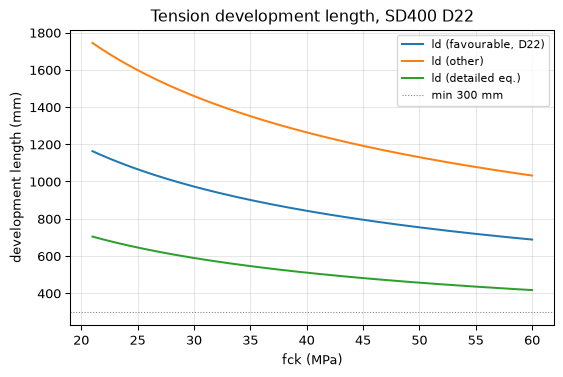

In [4]:
fck = np.linspace(21, 60, 200)
fig, ax = plt.subplots(figsize=(6.5, 4))
ax.plot(
    fck,
    [development_length_tension(bar="D22", fy=FY, fck=float(f)) for f in fck],
    label="ld (favourable, D22)",
)
ax.plot(
    fck,
    [
        development_length_tension(
            bar="D22", fy=FY, fck=float(f), favourable_spacing=False
        )
        for f in fck
    ],
    label="ld (other)",
)
ax.plot(
    fck,
    [
        development_length_tension_detailed(
            bar="D22", fy=FY, fck=float(f), c=40, k_tr=15
        )
        for f in fck
    ],
    label="ld (detailed eq.)",
)
ax.axhline(300, ls=":", color="grey", lw=0.8, label="min 300 mm")
ax.set_xlabel("fck (MPa)")
ax.set_ylabel("development length (mm)")
ax.set_title("Tension development length, SD400 D22")
ax.legend(fontsize=8)
ax.grid(alpha=0.3)
plt.show()

정밀식은 횡방향 철근에 의한 구속을 반영해 기본식보다 짧게 나온다.

## 철근 최소 순간격 (KDS 14 20 50 4.2)

In [5]:
print(f"{'호칭':>6} {'보':>10} {'기둥':>10} {'보(골재25)':>13}")
print("-" * 44)
for bar in ["D13", "D16", "D22", "D25", "D32", "D38"]:
    print(
        f"{bar:>6}"
        f" {minimum_bar_spacing(bar=bar, member='보'):10.1f}"
        f" {minimum_bar_spacing(bar=bar, member='기둥'):10.1f}"
        f" {minimum_bar_spacing(bar=bar, member='보', aggregate_size=25):13.1f}"
    )

    호칭          보         기둥       보(골재25)
--------------------------------------------
   D13       25.0       40.0          33.3
   D16       25.0       40.0          33.3
   D22       25.0       40.0          33.3
   D25       25.4       40.0          33.3
   D32       31.8       47.7          33.3
   D38       38.1       57.2          38.1
